# Installing Libraries:

In [ ]:
%pip install unstructured "unstructured[pdf]" htmltabletomd

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Install the core inference engine
%pip install unstructured-inference

# Install layoutparser and unstructured-pytesseract for layout detection
%pip install layoutparser unstructured-pytesseract


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
# Force-reset the Windows Package Manager source indexing
!winget source reset --force

# Install Tesseract using its exact system package ID
!winget install --id UB-Mannheim.TesseractOCR --accept-source-agreements --accept-package-agreements

# Install Poppler using its exact system package ID
!winget install --id oschwartz10612.poppler-windows --accept-source-agreements --accept-package-agreements

This command requires administrator privileges to execute.
Found Tesseract-OCR - open source OCR engine [UB-Mannheim.TesseractOCR] Version 5.4.0.20240606
This application is licensed to you by its owner.
Microsoft is not responsible for, nor does it grant any licenses to, third-party packages.
Successfully verified installer hash
Starting package install...
No package found matching input criteria.


In [1]:
%pip install python-dotenv

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Environment Setup:

In [ ]:
from dotenv import load_dotenv
import os

load_dotenv()
openai_api_key = os.environ["OPENAI_API_KEY"]

In [3]:
from langchain_openai import ChatOpenAI
chatgpt = ChatOpenAI(model="gpt-4o-mini")

In [4]:
from langchain_openai import OpenAIEmbeddings
openai_embed_model = OpenAIEmbeddings(model="text-embedding-3-small")

# Loading Data:

In [8]:
# Setting up tessaract-ocr and poppler-utils path - To execute UnstructedPDFLoader

import os
import unstructured_pytesseract

# 1. Direct Python to the freshly installed Tesseract binary
tesseract_bin_path = r"C:\Program Files\Tesseract-OCR\tesseract.exe"
unstructured_pytesseract.pytesseract.tesseract_cmd = tesseract_bin_path

# 2. Register the supporting folders with your active system path
required_runtime_paths = [
    r"C:\Program Files\Tesseract-OCR",
    r"C:\Program Files\poppler-26.02.0\Library\bin"
]

for directory_path in required_runtime_paths:
    if directory_path not in os.environ["PATH"]:
        os.environ["PATH"] += os.pathsep + directory_path


In [12]:
from langchain_community.document_loaders import UnstructuredPDFLoader

doc = "Project_2_AquaPure_X1_Multimodal_Manual.pdf"

loader = UnstructuredPDFLoader(file_path=doc,
                               strategy="hi_res",
                               extract_images_in_pdf=True,
                               infer_table_structure=True,
                               chunking_strategy="by_title",
                               max_characters=2500,
                               combine_text_under_n_chars=1000,
                               mode="elements",
                               image_output_dir_path = "./figures")

texts = loader.load()
print(len(texts))


C:\Users\Abhishek\AppData\Local\Temp\ipykernel_6120\1099713550.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import UnstructuredPDFLoader
No languages specified, defaulting to English.


Loading weights:   0%|          | 0/367 [00:00<?, ?it/s]

3


In [13]:
print("Total elements in texts:", len(texts))

print("Tables in texts:",
      sum(1 for d in texts if d.metadata["category"] == "Table"))

print("CompositeElements in texts:",
      sum(1 for d in texts if d.metadata["category"] == "CompositeElement"))

Total elements in texts: 3
Tables in texts: 1
CompositeElements in texts: 2


In [14]:
for i,d in enumerate(texts):
  print(i, d.metadata["category"])

0 CompositeElement
1 CompositeElement
2 Table


# Seperating table and text from "texts":

In [15]:
docs = []
tables = []

for text in texts:
    if text.metadata["category"] == "Table":
        tables.append(text)
    else:
        docs.append(text)


print(len(docs))
print(len(tables))

2
1


In [16]:
# converting html table to .md file:
import htmltabletomd

for table in tables:
    table.page_content = htmltabletomd.convert_table(table.metadata["text_as_html"])
    print(table.page_content)
    print()

| | | |
| :--- | :--- | :--- |
| Problem | Likely cause | Action |
| Low water flow | Pre-filter restriction | Inspect/replace pre-filter; run Flush |
| Unusual taste | Carbon filter exhausted | Check carbon filter status |
| Filter indicator red | Filter-life threshold | Identify indicated stage and replace |
| Leak alarm | Water in base | Stop appliance; close inlet; contact service |
| Display not responding | Power/control issue | Power-cycle once; if unresolved, contact service |




# Image Extraction:

In [17]:
import os

figures_dir = "./figures"  

if os.path.exists(figures_dir):
    files = os.listdir(figures_dir)
    print(f"Total files found in directory: {len(files)}")
    print("Files list:", files)
else:
    print(f"Directory '{figures_dir}' does not exist yet. Ensure your loader has run successfully.")


Total files found in directory: 3
Files list: ['figure-1-1.jpg', 'figure-2-2.jpg', 'figure-3-3.jpg']


# Checking loaded Images:

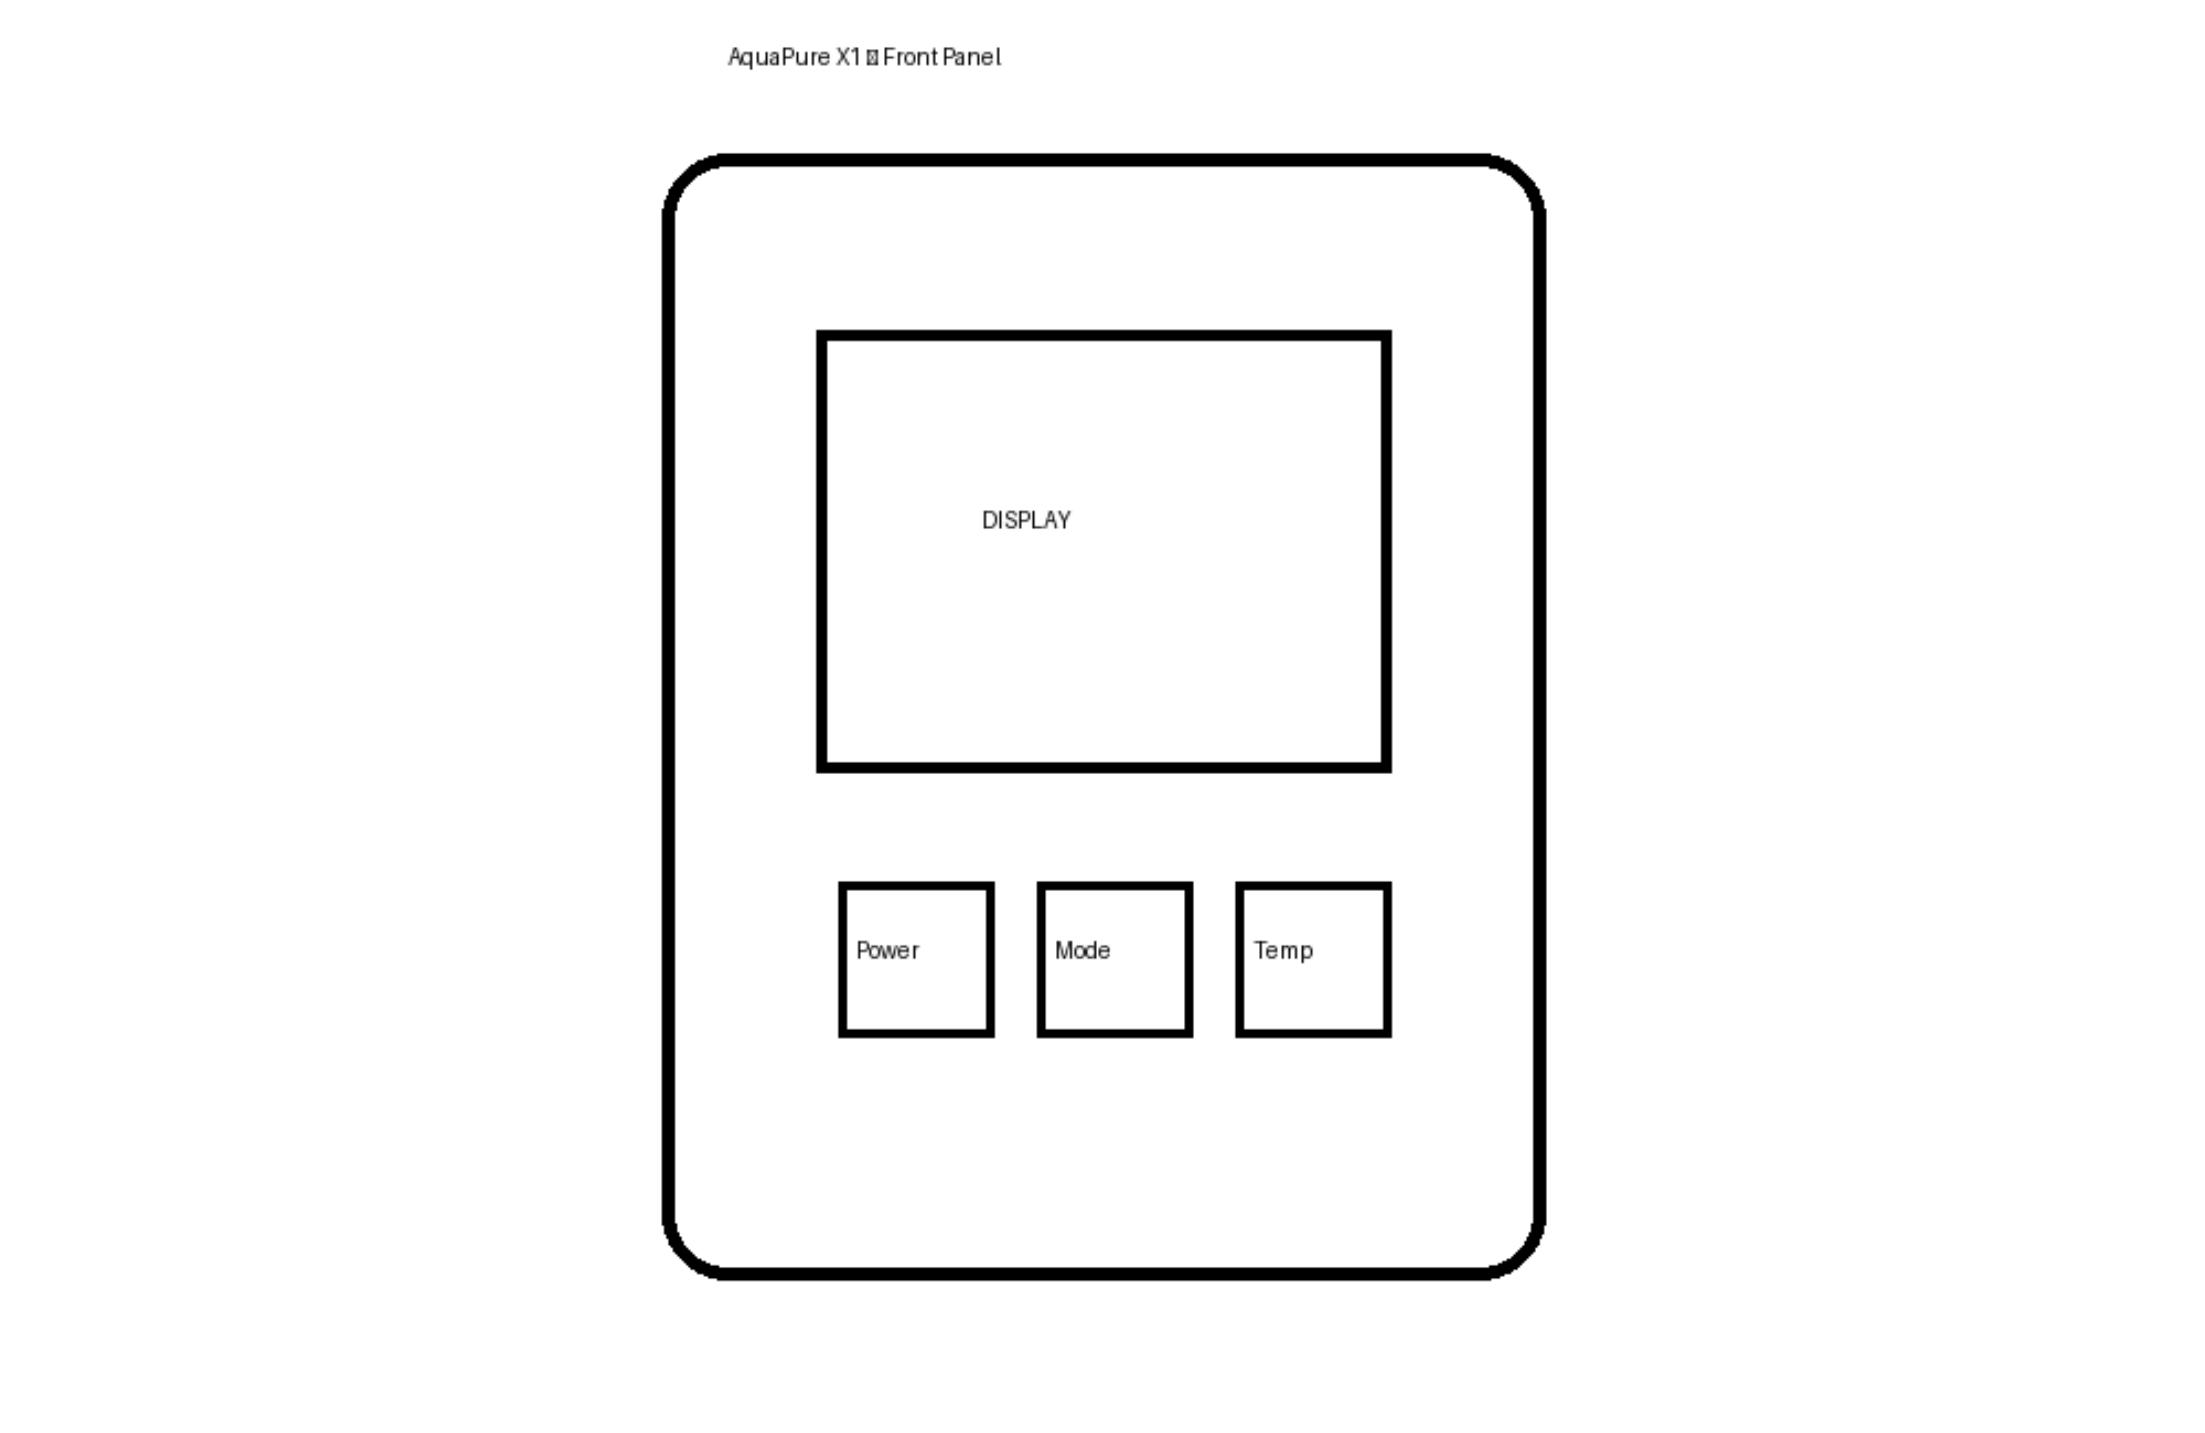

In [18]:
from IPython.display import Image

Image(r".\figures\figure-1-1.jpg")

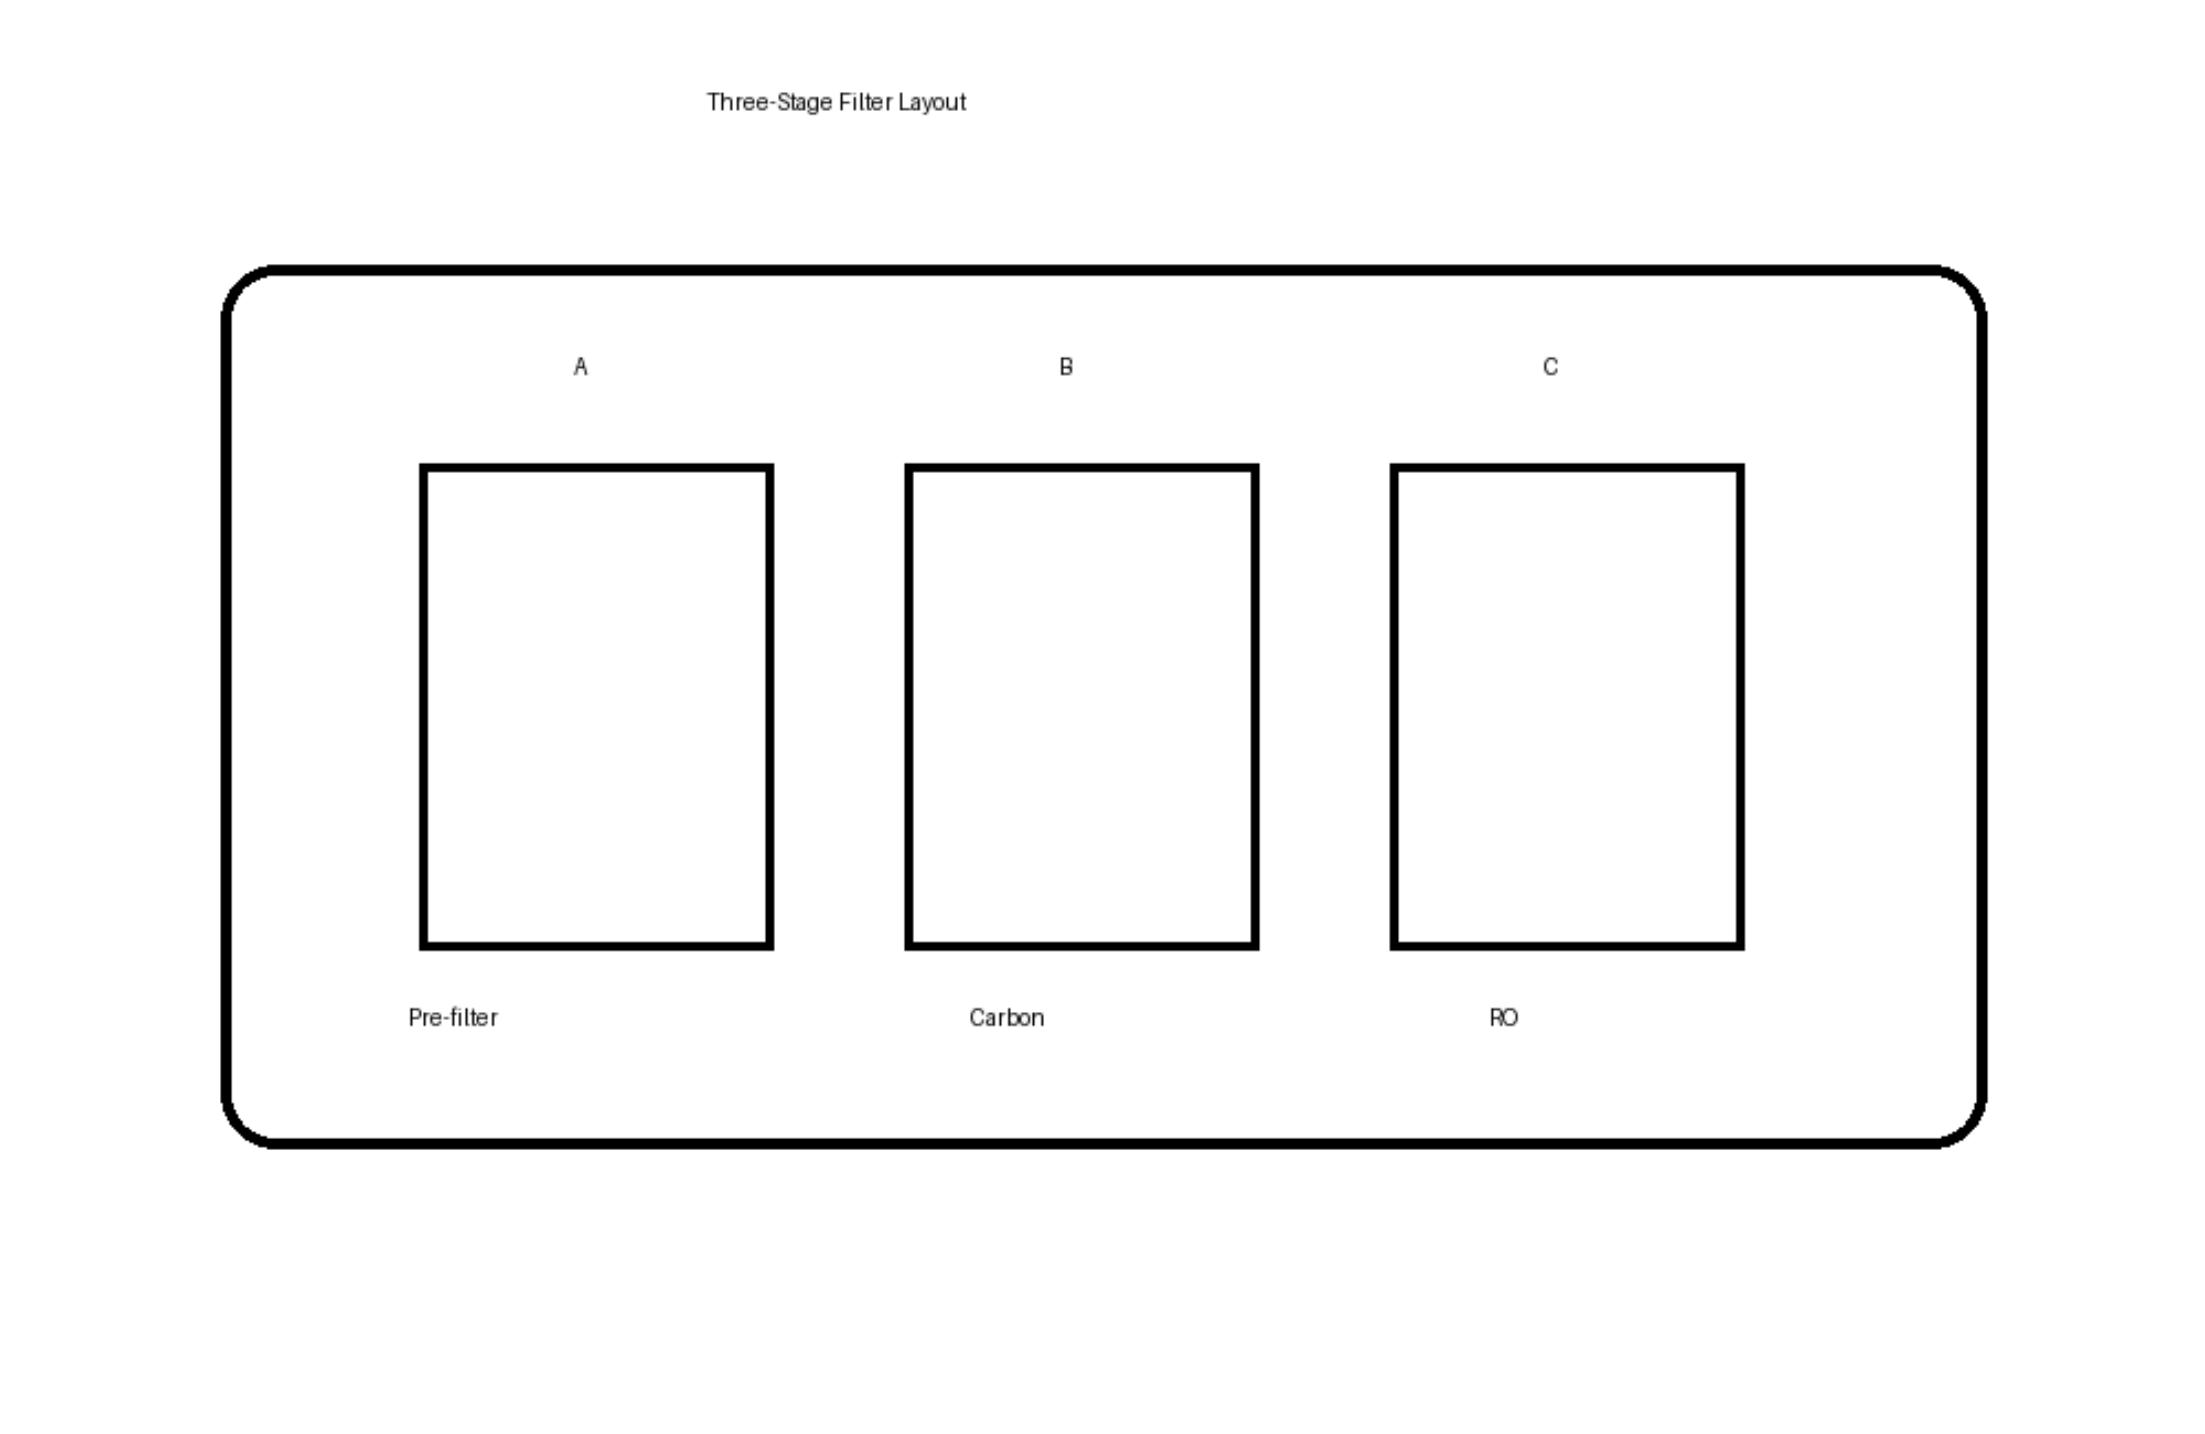

In [19]:
Image(r".\figures\figure-2-2.jpg")

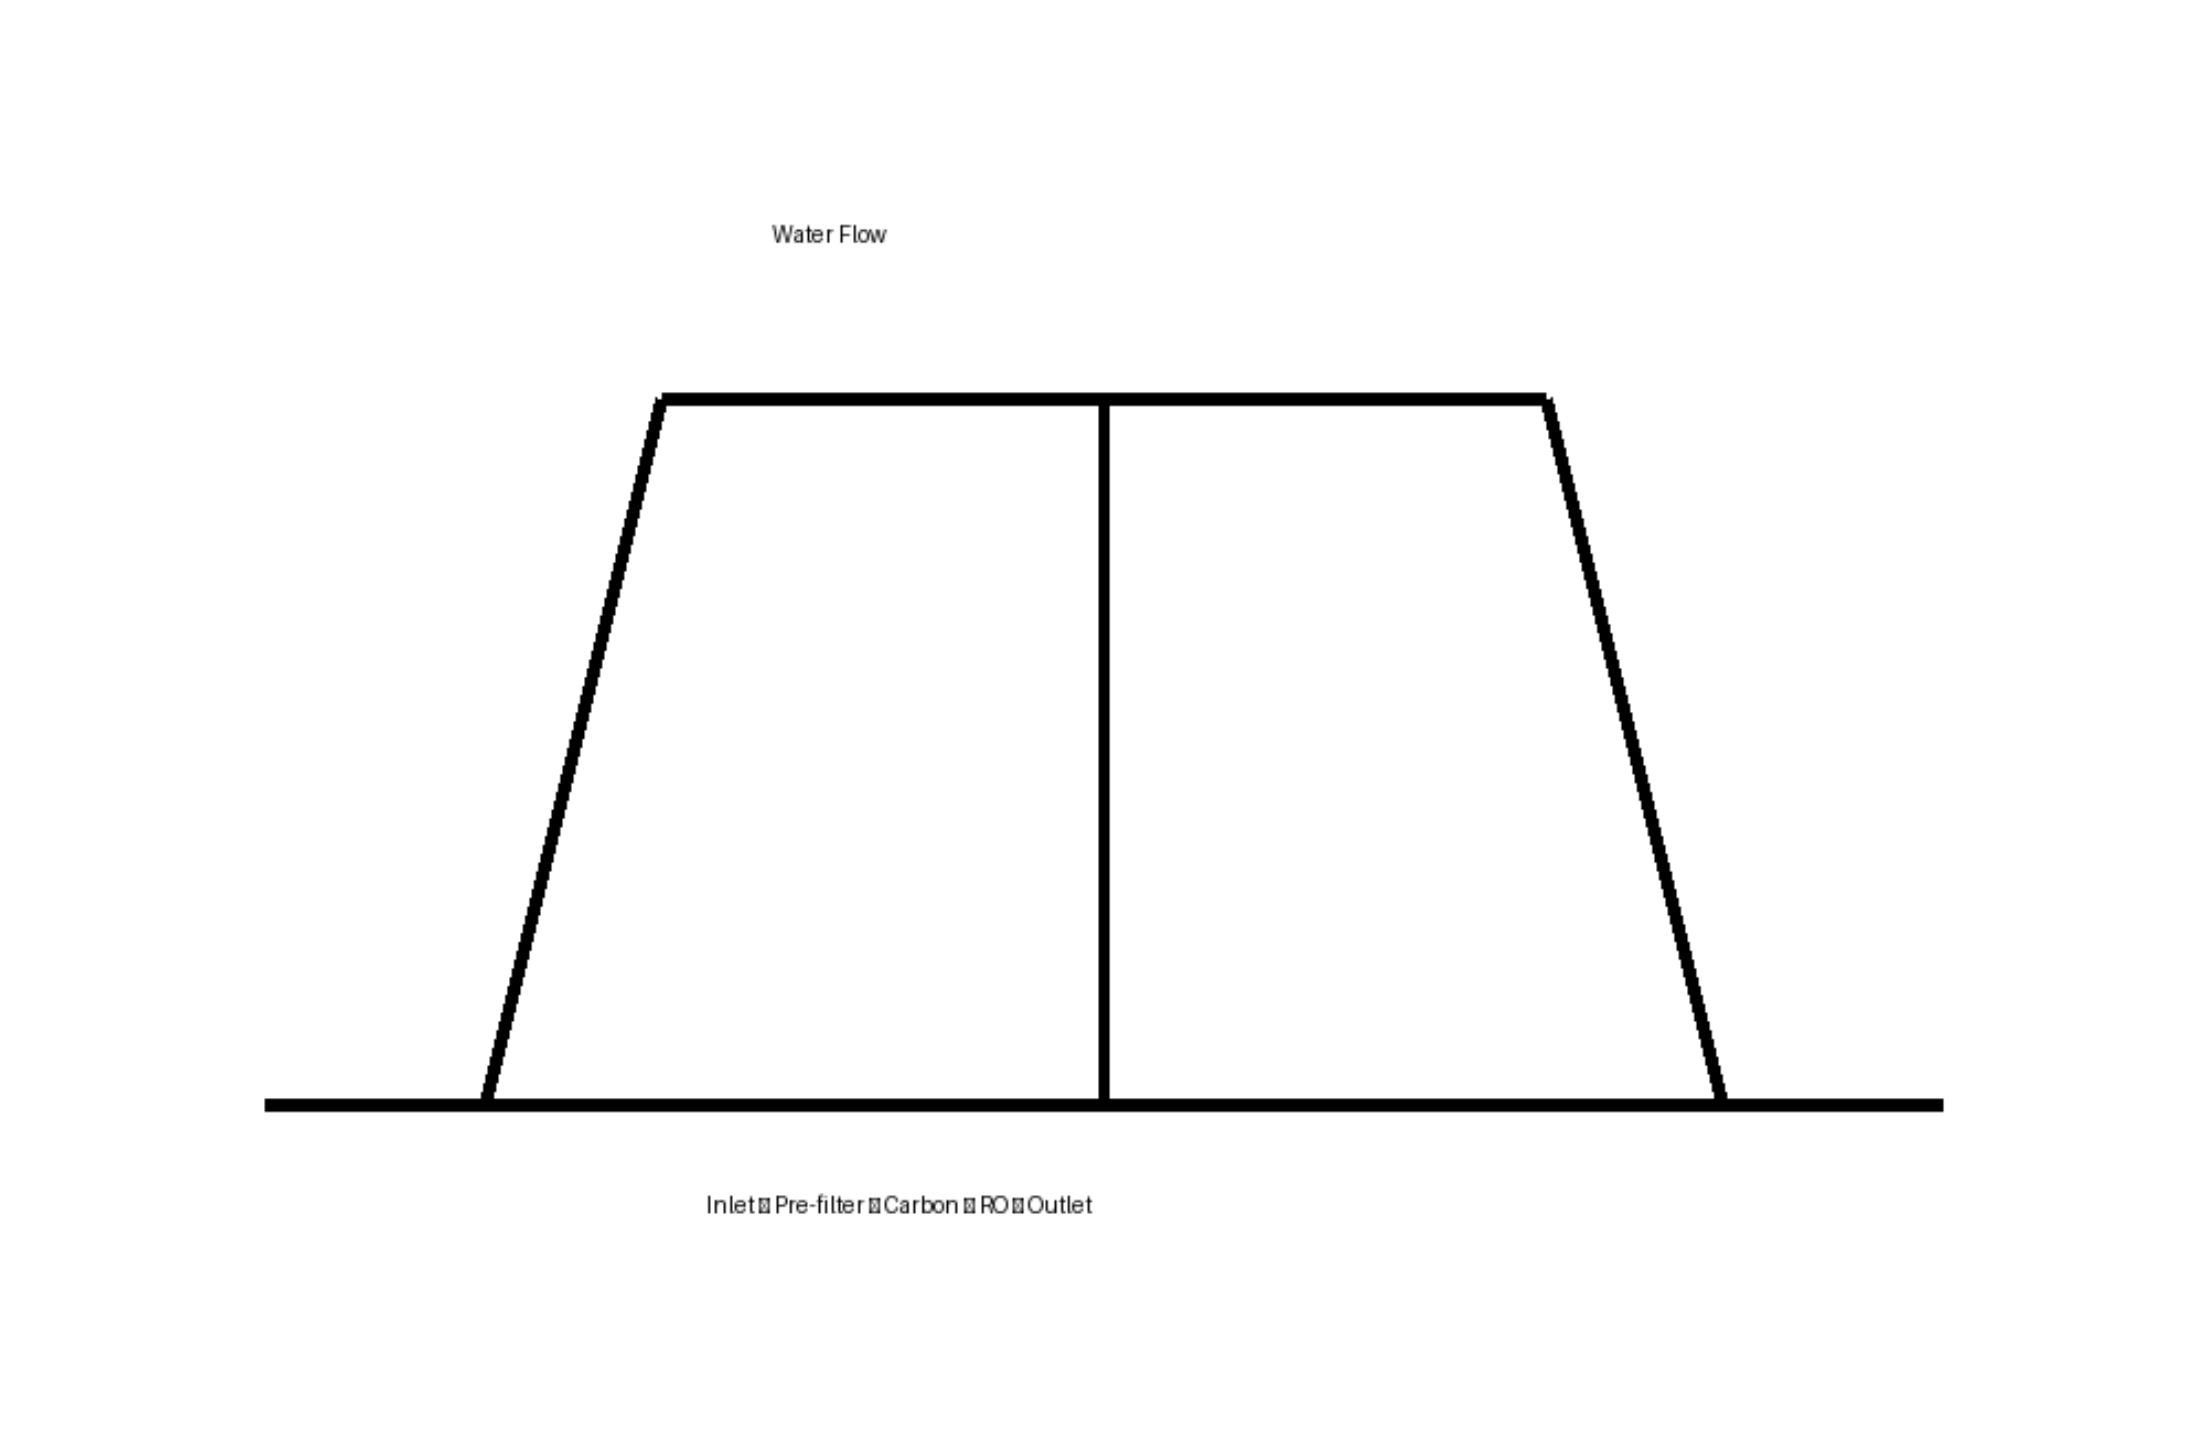

In [20]:
Image(r".\figures\figure-3-3.jpg")

# Text & Table summarization: 

In [21]:
# Prompt

prompt_text = """
    You are an assistant tasked with summarizing tables and text particularly for semantic retrieval.
    These summaries will be embedded and used to retrieve the raw text or table elements.
    Give a detailed summary of the table or text below that is well optimized for retrieval.
    For any tables also add in a one line description of what the table is about beside the summary.
    Do not add redundant words like Summary.
    Just output the actual summary content. Please use sophosticated and simple sentence.

    Table or Text chunk:
    {element}
    """

In [22]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

prompt = ChatPromptTemplate.from_template(prompt_text)

# Summarize chain

summarize_chain = (
    {"element": RunnablePassthrough()}
    | prompt
    | chatgpt
    | StrOutputParser()
)

In [23]:
text_summaries = []
table_summaries = []

text_docs = [doc.page_content for doc in docs]
table_docs = [table.page_content for table in tables]

text_summaries = summarize_chain.batch(text_docs)
table_summaries = summarize_chain.batch(table_docs)

In [24]:
print(len(text_summaries))
print(len(table_summaries))

2
1


In [25]:
print(text_summaries[0],"\n\n")
print(table_summaries[0])

User and Service Manual for AquaPure X1, a smart water purifier designed for home use.

The manual provides a detailed overview of the AquaPure X1, highlighting its innovative features including three-stage filtration, touch controls, filter-life monitoring, and an automated flushing system. It outlines three operating modes: Normal for standard use, Eco for efficient water use, and Flush for maintenance after filter changes. 

The filtration system consists of a pre-filter, carbon filter, and RO membrane arranged sequentially, with a recommended replacement schedule of every 6 months for the pre-filter, 9 months for the carbon filter, and 18 months for the RO membrane, ensuring optimal performance. 

Additionally, maintenance guidance is included for addressing issues like low water flow, unusual taste or odor, and leaks, advising users to clean or replace filters as necessary and to contact professional service when leaks are detected. 


This table outlines common problems encounter

# Image Summarization:

In [26]:
# Encoding the image:

import base64

def b64_encode(path):
    with open(path, 'rb') as f:
        return base64.b64encode(f.read()).decode('utf-8')

In [27]:
# Summarize image:

from langchain_core.messages import HumanMessage

def image_summarize(image_b64, prompt):
    chat = ChatOpenAI(model="gpt-4o-mini", temperature=0)
    msg = chat.invoke(
        [
            HumanMessage(
                content = [
                    {"type":"text", "text": prompt},
                    {"type": "image_url", "image_url": {"url":f"data:image/jpeg;base64,{image_b64}"}}
                ]
            )
        ]
    )

    return msg.content

In [28]:
# final function which executes both above function - to achieve both b64_image, summarized_image

import os

def generate_image_summary(path): 

    img_base64_list = []
    image_summaries = []

    prompt = """
        You are an expert assistant tasked with analyzing and detailing images for downstream semantic vector retrieval.
        This description will be embedded, and user search queries will be matched against it to find this specific image.
        
        Provide an exhaustive, highly descriptive breakdown of the image. You must include:
        1. The core subject matter or system component being visualized.
        2. All visible text, labels, annotations, headers, or identifiers exactly as they appear in the diagram (e.g., specific buttons, flow paths, step numbers).
        3. Structural details: list every component, layout feature, block, or box shown in the illustration.
        
        Do not add meta-commentary or redundant prefixes like "Summary:" or "This image displays...". 
        Output only the rich, descriptive keywords and explanatory sentences. Use sophisticated yet direct phrasing optimized for search engine matching.
        """


    for img_file in sorted(os.listdir(path)):
        if img_file.endswith(".jpg"):
            img_path = os.path.join(path, img_file)
            base64_image = b64_encode(img_path)

            img_base64_list.append(base64_image)
            image_summaries.append(image_summarize(base64_image, prompt))

    return img_base64_list, image_summaries

In [29]:
IMG_PATH = "./figures"

img_base64_list, image_summaries = generate_image_summary(IMG_PATH)

In [30]:
img_base64_list

['...']

In [31]:
image_summaries

['AquaPure X1 Front Panel visualization. Central rectangular display area labeled "DISPLAY" prominently positioned in the middle. Below the display, three rectangular buttons arranged horizontally. The left button is labeled "Power," the center button is labeled "Mode," and the right button is labeled "Temp." The overall design features rounded corners, creating a sleek and modern aesthetic. The panel is outlined with a bold border, emphasizing its structure. The top of the panel includes the title "AquaPure X1 Front Panel," indicating the specific model being represented.',
 'Three-stage filter layout diagram featuring three distinct filter components arranged horizontally. The top section is labeled "Three-Stage Filter Layout." \n\nVisible components include:\n- Three rectangular boxes labeled A, B, and C, each representing a stage in the filtration process.\n- The leftmost box (A) is labeled "Pre-filter," indicating the initial stage of filtration.\n- The middle box (B) is labeled "

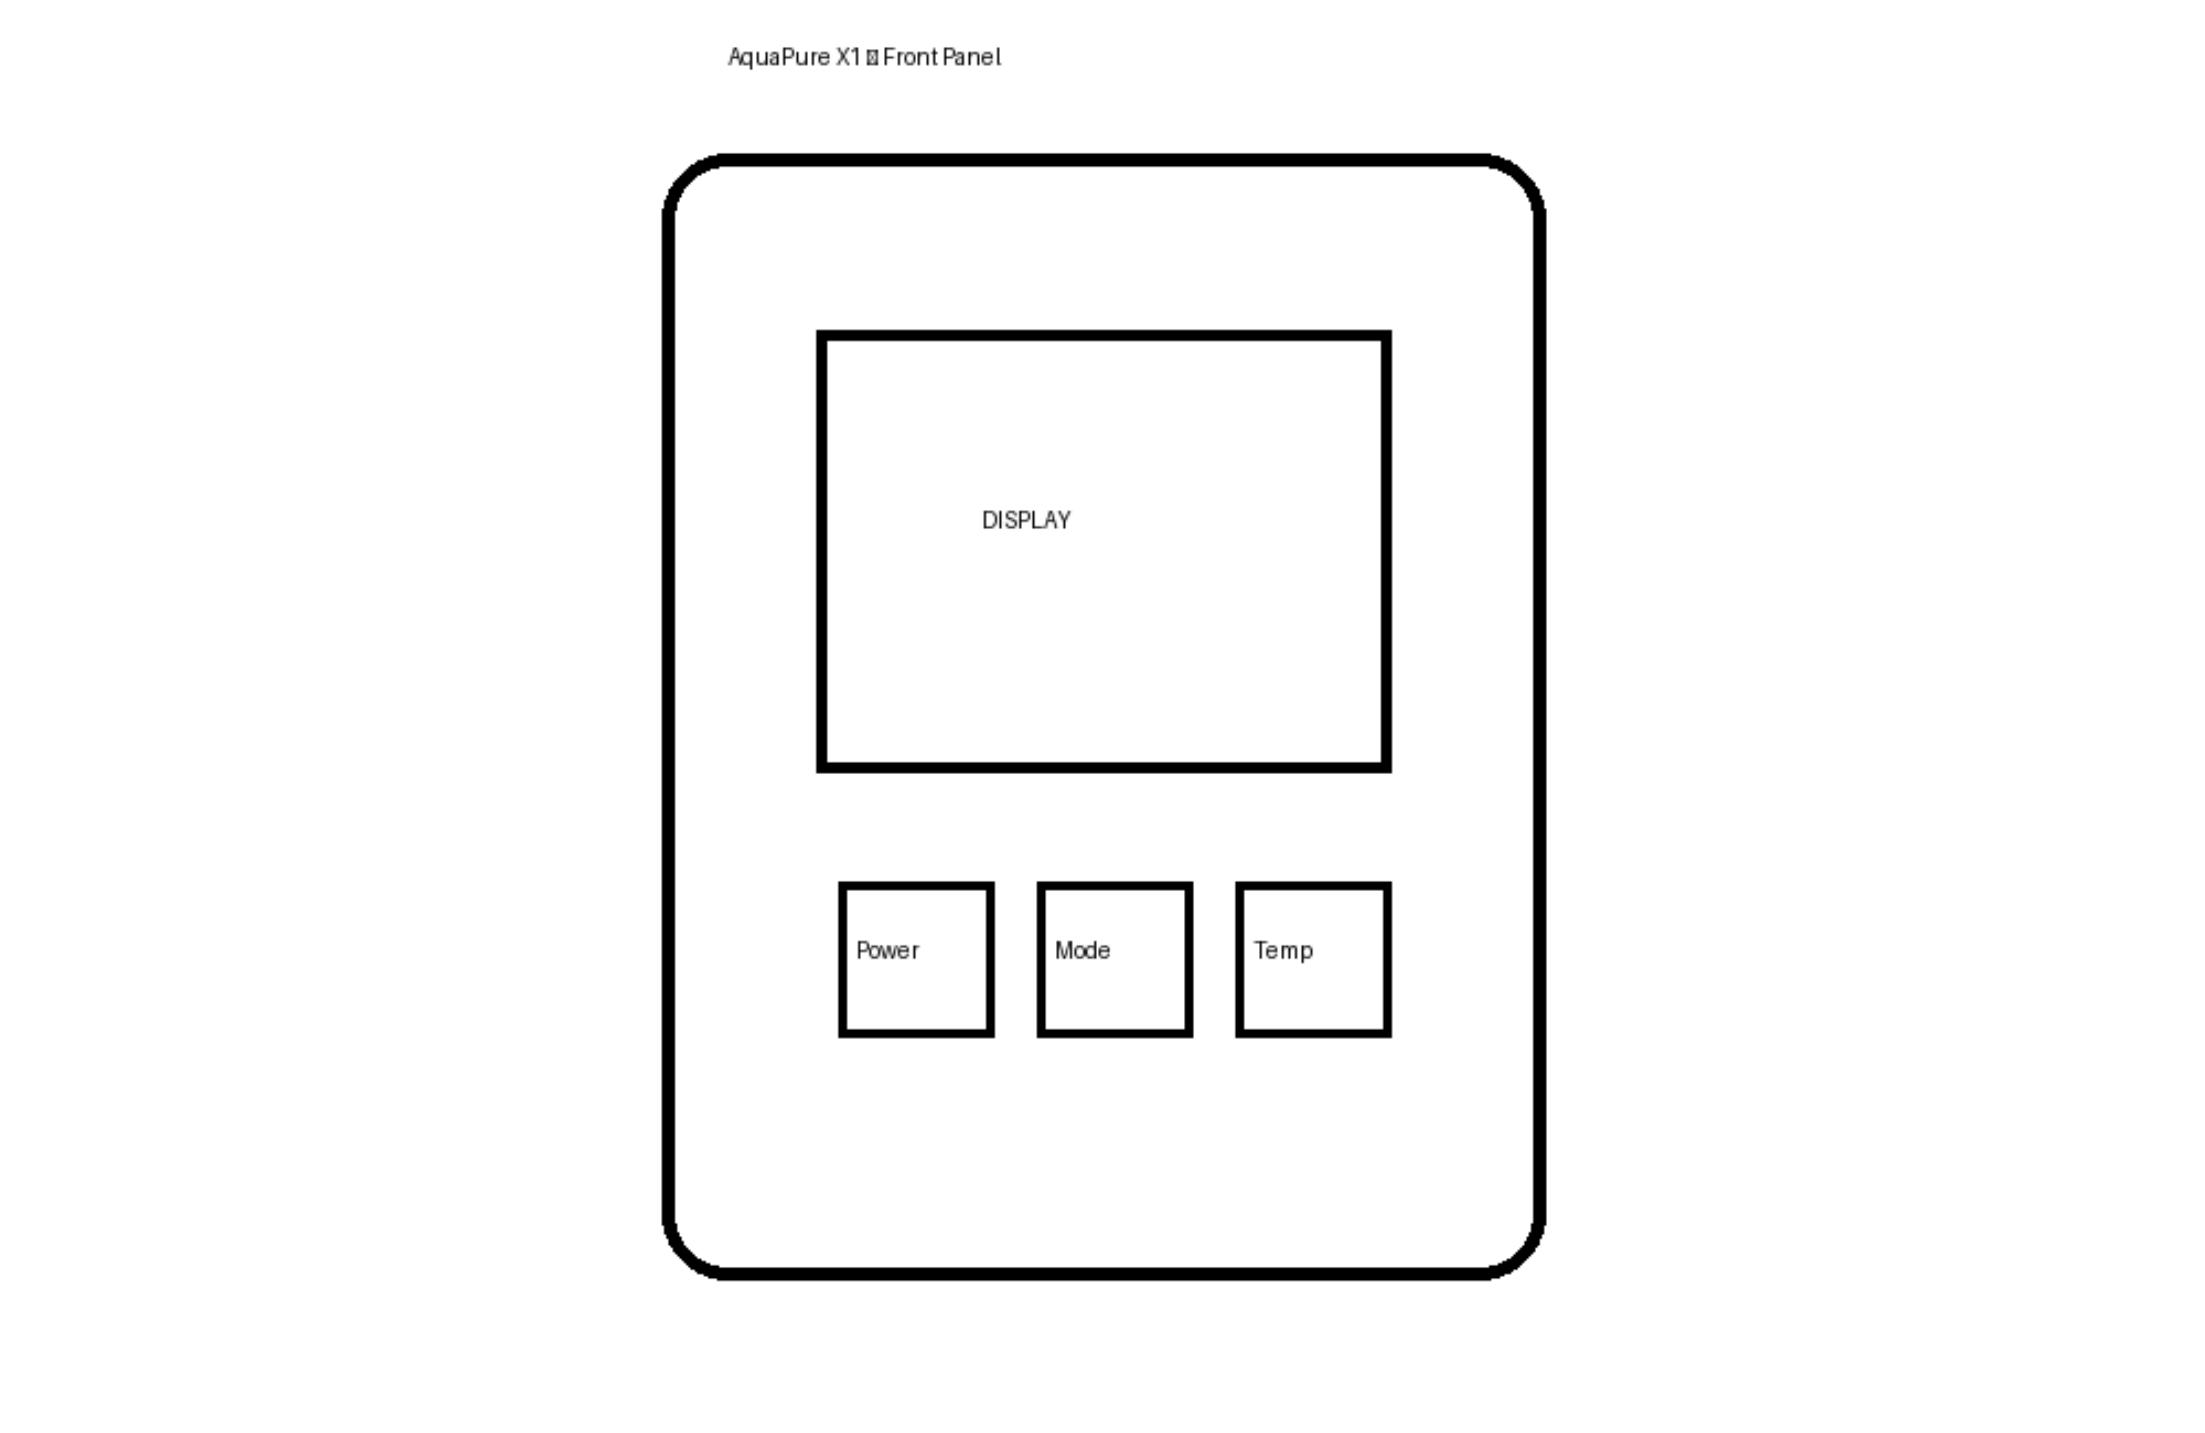

Figure 01 Summary: 
 AquaPure X1 Front Panel visualization. Central rectangular display area labeled "DISPLAY" prominently positioned in the middle. Below the display, three rectangular buttons arranged horizontally. The left button is labeled "Power," the center button is labeled "Mode," and the right button is labeled "Temp." The overall design features rounded corners, creating a sleek and modern aesthetic. The panel is outlined with a bold border, emphasizing its structure. The top of the panel includes the title "AquaPure X1 Front Panel," indicating the specific model being represented.


In [32]:
display(Image(r".\figures\figure-1-1.jpg"))
print(f"Figure 01 Summary: \n {image_summaries[0]}")

# Chroma db and Redis store:

In [39]:
%pip install redis
%pip install langchain-classic

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
import os
import uuid
from langchain_classic.retrievers import MultiVectorRetriever
from langchain_community.storage import RedisStore
from langchain_community.utilities.redis import get_client
from langchain_chroma import Chroma
from langchain_core.documents import Document

os.environ["ANONYMIZED_TELEMETRY"] = "false"

In [51]:
def create_multi_vector_retriever(
        docstore, vectordb, text_summaries, texts, table_summaries, tables, image_summaries, images
):
    """
    Create retriever that indexes summaries, but returns raw images or texts
    """
    id_key = "doc_id"

    # Create multi-vector retriever instance:
    retriever = MultiVectorRetriever(
        vectorstore=vectordb,
        docstore= docstore,
        id_key=id_key
    )

    def add_documents(retriever, doc_summaries, doc_contents, asset_type):
        doc_ids = [str(uuid.uuid4()) for _ in doc_contents]
        
        # Build summary Document wrappers for the Chroma database index
        summary_docs = [
            Document(page_content=s, metadata={id_key: doc_ids[i], "type": asset_type})
            for i, s in enumerate(doc_summaries)
        ]
        retriever.vectorstore.add_documents(summary_docs)
        
        
        # Set documents into the Redis store layer
        retriever.docstore.mset(list(zip(doc_ids, doc_contents)))

    # Ingest distinct data types with explicit tracking labels
    if text_summaries and texts:
        add_documents(retriever, text_summaries, texts, asset_type="text")
        
    if table_summaries and tables:
        add_documents(retriever, table_summaries, tables, asset_type="table")
        
    if image_summaries and images:
        add_documents(retriever, image_summaries, images, asset_type="image")

    return retriever


In [52]:
#  creating a chroma_db:

from langchain_chroma import Chroma
# The vectorstore to use to index the summaries and their embeddings
chroma_db = Chroma(
    collection_name="mm_rag",
    embedding_function=openai_embed_model,
    collection_metadata={"hnsw:space": "cosine"},
    persist_directory="./chroma_db"
)

In [53]:
# Initializing redis store
 
import redis

try:
    # Use decode_responses=True ONLY for this quick connection ping test
    test_client = redis.Redis(host='localhost', port=6379, decode_responses=True)
    if test_client.ping():
        print(" --> Python successfully connected to the Docker Redis container on port 6379!")
except Exception as e:
    print(" Connection failed! Make sure Docker Desktop is open and running.")


 --> Python successfully connected to the Docker Redis container on port 6379!


In [54]:
client = get_client('redis://localhost:6379')
redis_store = RedisStore(client=client, namespace="aquapure_p2_multi_rag") 

# Retriever:

In [55]:
retriever_multi_vector = create_multi_vector_retriever(
    redis_store,
    chroma_db,
    text_summaries,
    text_docs,
    table_summaries,
    table_docs,
    image_summaries,
    img_base64_list
)

In [56]:
retriever_multi_vector

MultiVectorRetriever(vectorstore=<langchain_chroma.vectorstores.Chroma object at 0x0000017684D43590>, docstore=<langchain_community.storage.redis.RedisStore object at 0x0000017684D43550>, search_kwargs={})

# separating texts and images from retriever:

In [57]:
import re

# Checks whether the string contains only valid Base64 characters.
def looks_like_base64(sb):
    """Check if the string looks like base64"""
    return re.match("^[A-Za-z0-9+/]+[=]{0,2}$", sb) is not None

# IS IT TRULY AN IMAGE BY CHECKING THE STARTING OF THE BASE64. EVERY IMAGE STARTS WITH THESE BYTES
def is_image_data(b64data):
    """
    Check if the base64 data is an image by looking at the start of the data
    """
    image_signatures = {
        b"\xff\xd8\xff": "jpg",
        b"\x89\x50\x4e\x47\x0d\x0a\x1a\x0a": "png",
        b"\x47\x49\x46\x38": "gif",
        b"\x52\x49\x46\x46": "webp",
    }
    try:
        header = base64.b64decode(b64data)[:8]  # Decode and get the first 8 bytes
        for sig, format in image_signatures.items():
            if header.startswith(sig):
                return True
        return False
    except Exception:
        return False


def split_image_and_text(docs):
    """
    Split base64-encoded images and texts safely checking for string/bytes objects
    """    
    b64_images = []
    texts = []
    
    for doc in docs:
        # Extract content whether it's wrapped in a LangChain Document or a raw database string
        if hasattr(doc, "page_content"):
            content = doc.page_content
        else:
            content = doc
            
        if isinstance(content, bytes):
            content = content.decode('utf-8')
            
        if looks_like_base64(content) and is_image_data(content):
            b64_images.append(content)
        else:
            texts.append(content)
            
    return {"images": b64_images, "texts": texts}

# Augmentation Part:

In [59]:
def multimodal_prompt_function(data_dict):
    """Formats retrieved vector sources cleanly for the Generation Chain"""
    formatted_texts = "\n\n".join(data_dict["context"]["texts"])
    messages = []

    # Inject images as explicit image blocks if present in context
    if data_dict["context"]["images"]:
        for image in data_dict["context"]["images"]:
            image_message = {
                "type": "image_url",
                "image_url": {"url": f"data:image/jpeg;base64,{image}"},
            }
            messages.append(image_message)

    # Core instruction text block mapping
    text_message = {
        "type": "text",
        "text": (
            f"""You are an expert analyst whose main goal is to carefully understand and explain information found in text documents, data tables, and visual materials such as charts or graphs in images.

You will receive context information below. This context may include a combination of:
* Written text or paragraphs
* Structured data in tables
* Images that contain charts, graphs, or any kind of visual data

Your task is to:
1. Study all the provided materials together — the text, tables, and images.
2. Identify patterns, relationships, and trends that can help answer the user’s question.
3. Form your answer only from the given context. Do not guess or invent information. If something is not mentioned or shown in the provided context, simply respond: "I don’t know, because that information is not available in the given context. Please ask a question related to the provided data."

When writing your response:
* Be as detailed as possible and show your reasoning clearly.
* Use simple, easy-to-understand language so that anyone can follow your explanation.
* Connect all the dots between the text, tables, and charts logically and coherently.
* Present your answer in an organized, thoughtful, and human-like way.

User question:
{data_dict['question']}

Context documents:
{formatted_texts}

Answer:"""
        ),
    }
    messages.append(text_message)
    return [HumanMessage(content=messages)]

# Generation part (LCEL):

In [60]:
# assigning top_k value to retriever
retriever_multi_vector.search_kwargs = {"k": 5}


from operator import itemgetter
from langchain_core.runnables import RunnableLambda, RunnablePassthrough

# Generate answer chain
multimodal_rag = (
    {
        "context": itemgetter('context'),
        "question": itemgetter('input'),
    }
    | RunnableLambda(multimodal_prompt_function)
    | chatgpt
    | StrOutputParser()
)

# Fetch and sort context assets
retrieve_docs = (
    itemgetter('input')
    | retriever_multi_vector
    | RunnableLambda(split_image_and_text)
)

# Combine elements into a cohesive source tracker
multimodal_rag_w_sources = (RunnablePassthrough.assign(context=retrieve_docs)
                                               .assign(answer=multimodal_rag)
)

# Testing the chain (entire RAG):

In [ ]:
import base64
from io import BytesIO
from IPython.display import display
from PIL import Image as PILImage 

def plt_img_base64(img_base64):
    """
    Decodes a Base64-encoded image string, converts it back into 
    a visible graphic format, and displays it inside the Jupyter Notebook.
    """
    try:
        # If the incoming data is a bytes object, decode it to a standard string first
        if isinstance(img_base64, bytes):
            img_base64 = img_base64.decode('utf-8')
            
        # Decode the base64 string back to raw image bytes
        img_data = base64.b64decode(img_base64)
        
        # Create an in-memory byte buffer
        img_buffer = BytesIO(img_data)
        
        # Open and render the image using PIL safely
        img = PILImage.open(img_buffer)
        display(img)
    except Exception as e:
        print(f" Could not render visual asset source: {e}")


In [64]:
from IPython.display import Markdown

def multimodal_rag_qa(query_string):
    """Executes search and prints text answers and original source components side-by-side"""

    response = multimodal_rag_w_sources.invoke({'input': query_string})
    
    print('=='*50)
    print(' ANSWER:')
    display(Markdown(response['answer']))
    print('--'*50)

    print(' RETRIEVED SOURCES USED:')
    text_sources = response['context']['texts']
    img_sources = response['context']['images']
    
    print(f"(Found {len(text_sources)} Text/Table chunks and {len(img_sources)} Images)")
    
    for idx, text in enumerate(text_sources):
        print(f"\n[Text Source {idx + 1}]:")
        display(Markdown(text))
        
    for idx, img in enumerate(img_sources):
        print(f"\n[Visual Diagram Source {idx + 1}]:")
        plt_img_base64(img)
        
    print('=='*50)

 ANSWER:


The three filtration stages of the AquaPure X1 water purifier, in order, are:

1. **Pre-filter (A)**: This is the first stage that removes larger particles and sediments from the water.
2. **Carbon filter (B)**: The second stage that eliminates chlorine, odors, and bad tastes from the water.
3. **Reverse Osmosis (RO) (C)**: The final stage that removes smaller contaminants and impurities from the water.

This order ensures that the water is progressively filtered for better quality, with each stage addressing specific impurities before the next.

----------------------------------------------------------------------------------------------------
 RETRIEVED SOURCES USED:
(Found 2 Text/Table chunks and 2 Images)

[Text Source 1]:


| | | |
| :--- | :--- | :--- |
| Problem | Likely cause | Action |
| Low water flow | Pre-filter restriction | Inspect/replace pre-filter; run Flush |
| Unusual taste | Carbon filter exhausted | Check carbon filter status |
| Filter indicator red | Filter-life threshold | Identify indicated stage and replace |
| Leak alarm | Water in base | Stop appliance; close inlet; contact service |
| Display not responding | Power/control issue | Power-cycle once; if unresolved, contact service |



[Text Source 2]:


AquaPure X1 — Smart Water Purifier User & Service Manual

Synthetic multimodal RAG training data. The manual contains both text and visual evidence.

Product overview: AquaPure X1 is a fictional home water purifier with three filtration stages, touch controls, filter-life monitoring, and an automatic flush cycle.

AquaPure X18 Front Panel DISPLAY

Figure 1: Front panel.

1. Operating modes

Normal: Default mode for everyday operation.

Eco: Reduces pump activity for lower water demand.

Flush: Cleaning cycle; use after filter replacement and when indicated.

Temperature: Changes output temperature only; it does not change filtration stages.

2. Filter system

Three-Stage Filter Layout Pre-filter

Figure 2: Water passes through Pre-filter (A), Carbon (B), and RO (C), in that order.

3. Water flow and maintenance

Water Flow Inleta Pre-filter @ Carbon & ROg Outlet

Figure 3: Water-flow sequence.

Replacement schedule: Pre-filter every 6 months; Carbon filter every 9 months; RO membrane every 18 months under normal household usage.

After replacement: Run one complete Flush cycle before returning to Normal mode.

Low flow: Check whether the pre-filter is clogged. If the filter indicator is red, inspect the pre-filter first.

Unusual taste/odor: Run Flush. If it continues, check carbon filter status.

Leak detected: Stop the appliance, close the inlet valve, and contact authorized service.


[Visual Diagram Source 1]:


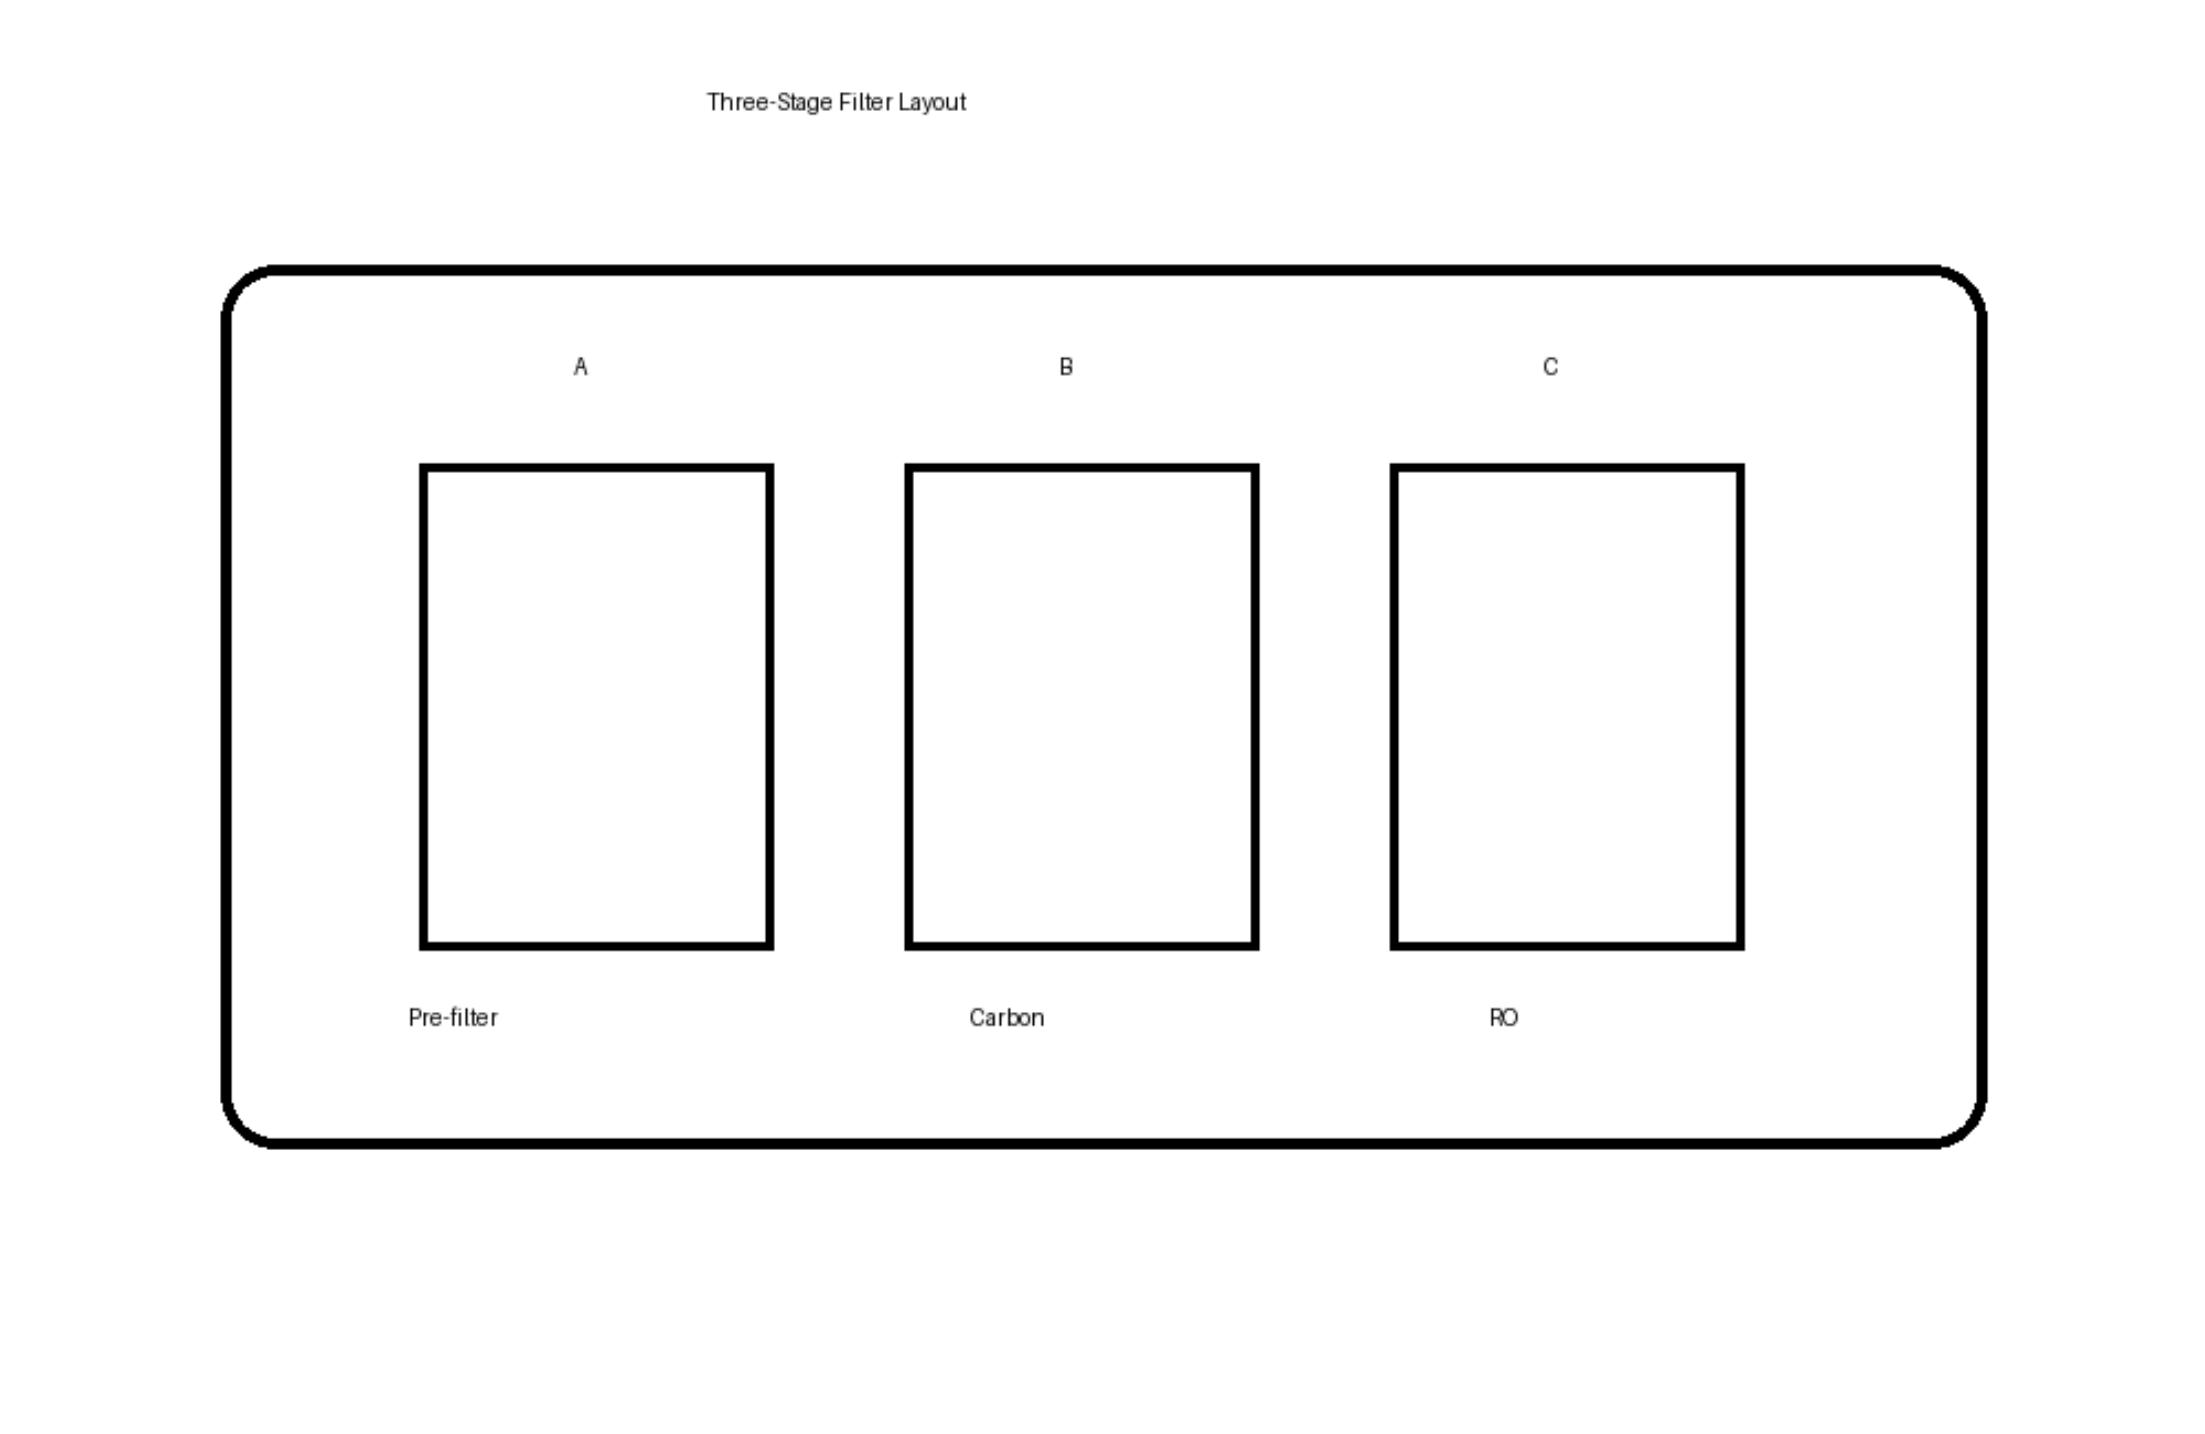


[Visual Diagram Source 2]:


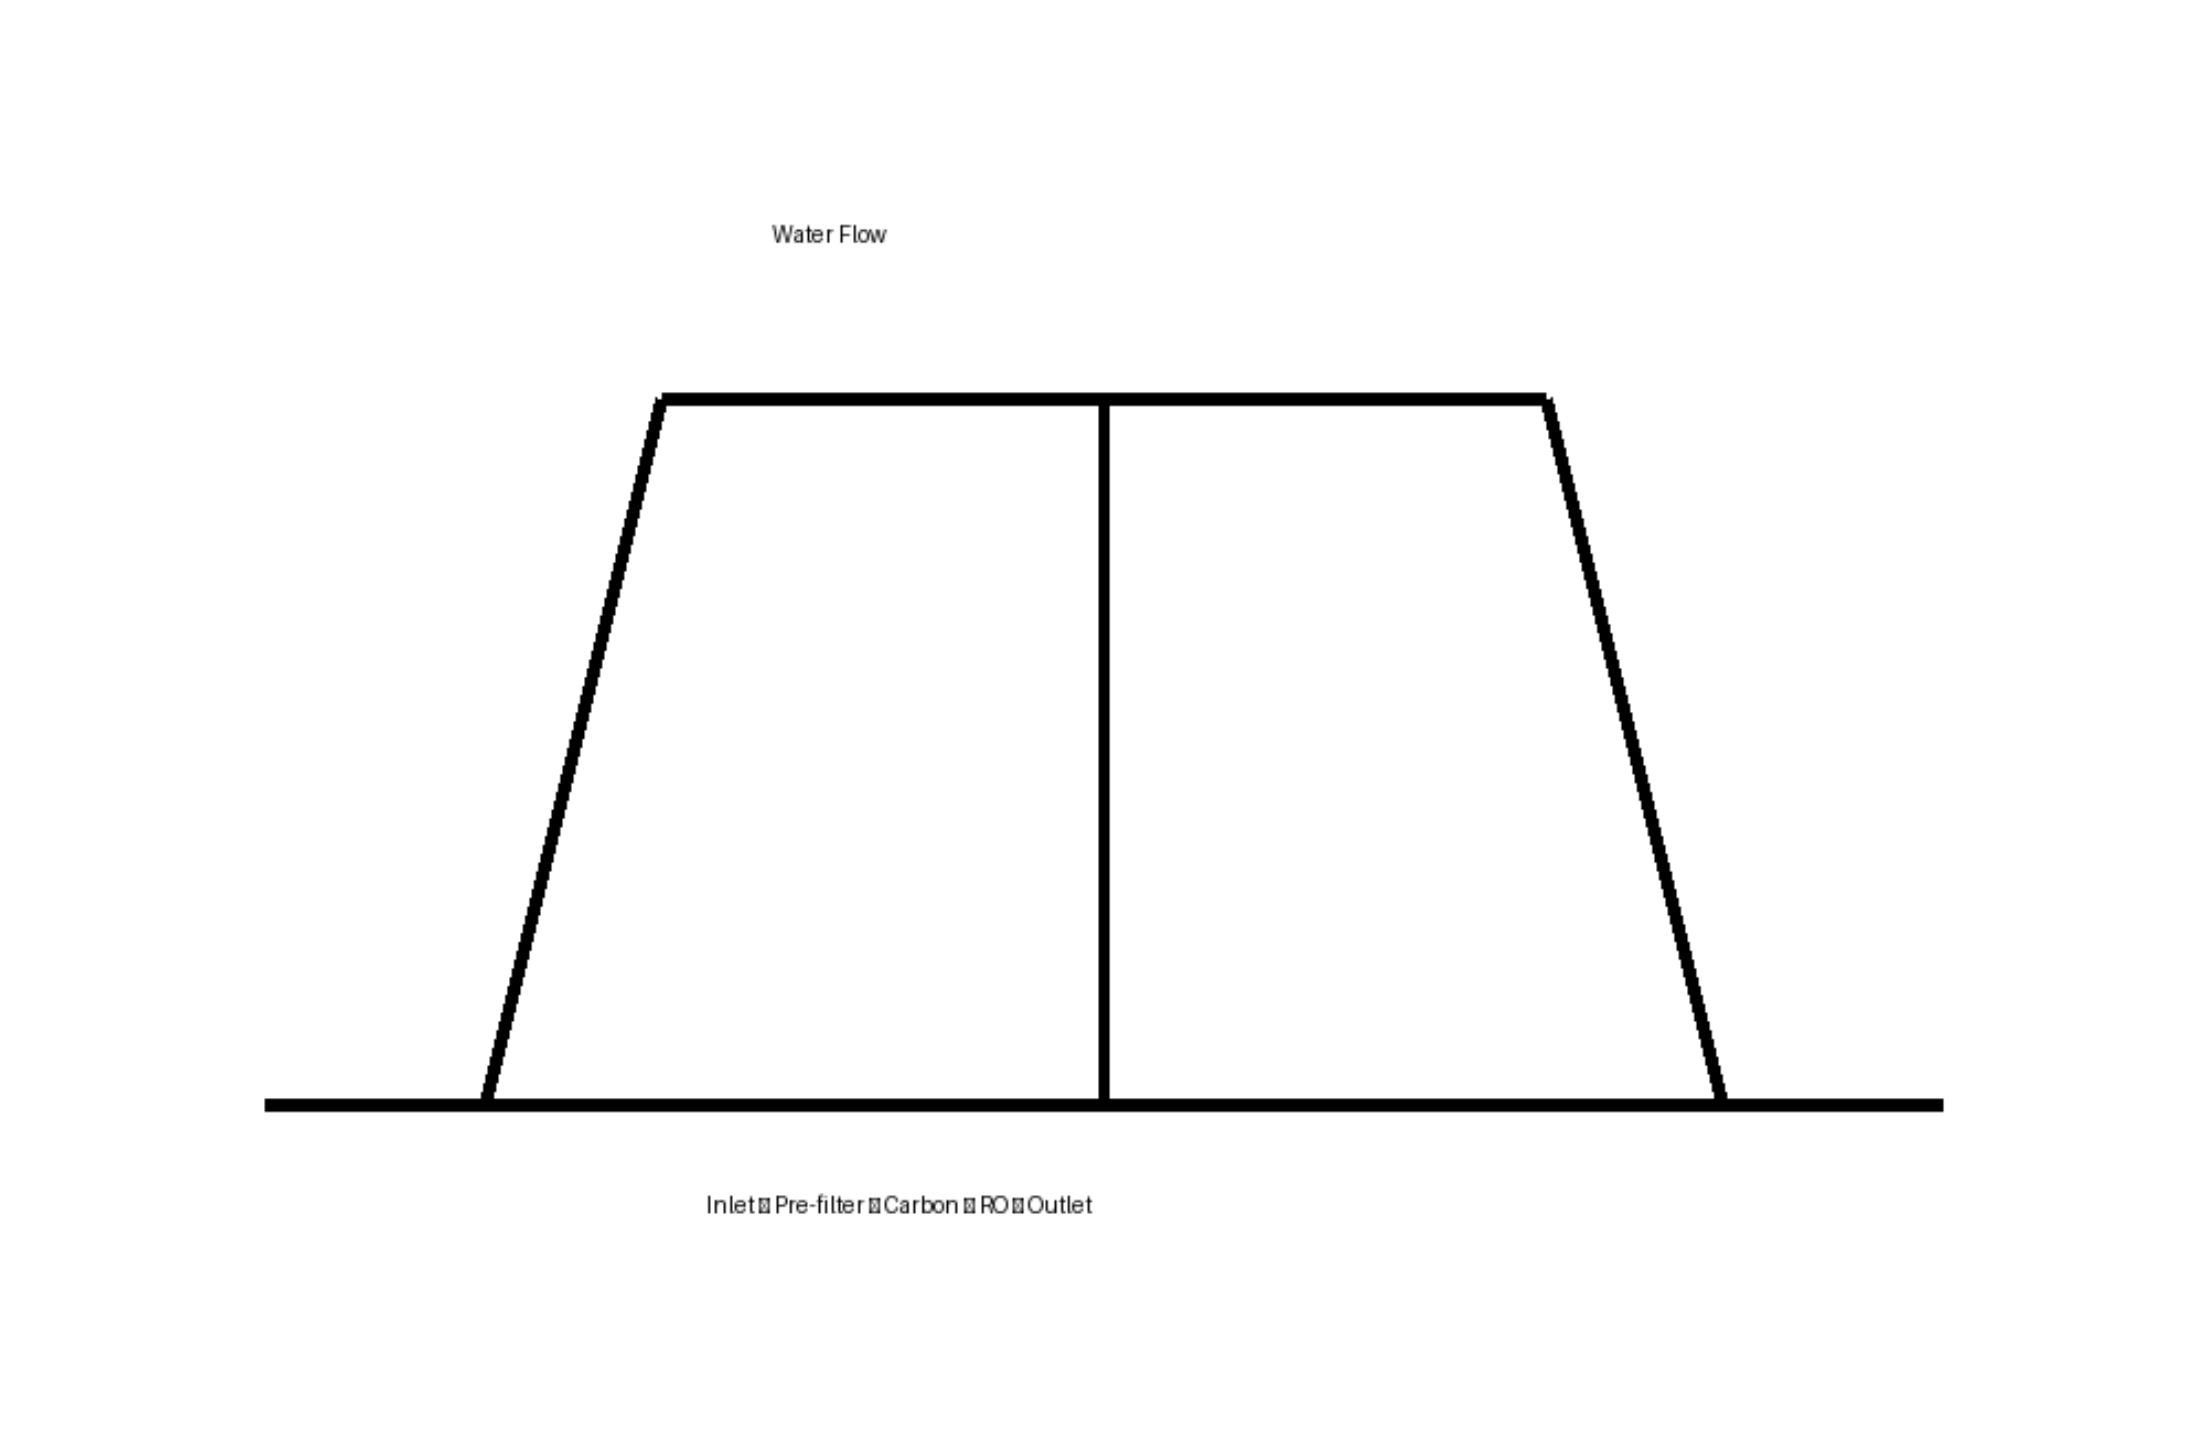

In [65]:
query = "What are the three filtration stages, in order?"
multimodal_rag_qa(query)